# How far to trust a continuous connectome

Test-retest reliability on HCP Young Adult data, and how the analysis choices move it.

Reliability decides what a connectome can be used for. This notebook measures it for the
package's continuous connectomes of HCP Young Adult subjects in three ways, with the
Schaefer-200 region matrices of the same files beside them wherever a result has a region
counterpart.

1. **FC across days.** The HCP scanned resting state on two days, two runs each (REST1 and
   REST2), and a hundred young adults' FC was built for each day on its own
   (`tools/build_hcp_fc.py --session`). How surely each day picks out its subject, how reliable
   one connection is, where a vertex's connectivity repeats, and how much of structure-function
   coupling survives a change of day.
2. **SC across halves of its streamlines.** Diffusion was scanned once, so thirty subjects'
   streamlines are split at random into two halves, each re-smoothed at three bandwidths
   (`scripts/reliability_data.py`). That measures what the finite number of streamlines costs,
   and how the smoothing bandwidth trades it against what makes a subject stand out. The halves
   share the scan, the tractography and the registration, so this is an upper bound on what a
   rescan would show.
3. **Components and alignment.** How reliably the functional PCA scores a subject, and how far
   ENCORE moves one half of a subject's streamlines onto the other -- alignment's own noise --
   against how far it moves another subject's.

The paths at the top are the lab's copies on Longleaf. As it stands the notebook runs in about
20 minutes on 8 cores, with 30 GB of memory at its peak.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

import sbci
from sbci.stats import icc, identification

# The lab's copies on Longleaf; point these at your own files.
ROOT = Path("/work/users/x/y/xya/hcp-ya")
FC_BY_DAY = ROOT / "reliability" / "fc"  # sub-<id>_ses-REST1_fc.h5 and sub-<id>_ses-REST2_fc.h5
SC = ROOT / "full" / "data"  # sub-<id>_sc.h5, one structural connectome a subject
SPLIT = ROOT / "reliability" / "split"  # what scripts/reliability_data.py wrote
OUT = ROOT / "reliability" / "maps"
OUT.mkdir(parents=True, exist_ok=True)

# The package's figure style: one blue for the continuous connectome, orange for the atlas.
BLUE, ORANGE, INK, MUTED, RULE = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e", "#d9d8d3"
BLUE_RAMP = LinearSegmentedColormap.from_list(
    "blue", ["#f4f8fd", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
)
SURFACE_RAMP = LinearSegmentedColormap.from_list(
    "surface", ["#b7d3f6", "#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281", "#0d366b"]
)
plt.rcParams.update({
    "font.size": 10, "text.color": INK, "axes.labelcolor": MUTED, "axes.edgecolor": RULE,
    "axes.spines.top": False, "axes.spines.right": False, "xtick.color": MUTED,
    "ytick.color": MUTED, "figure.facecolor": "white", "figure.dpi": 110,
})


def surface(values, title, scale=None):
    """A map on fsaverage, as the package's figures are drawn.

    ``scale`` fixes the colour range, so that two maps can be compared; without
    it the map is coloured over its own 2nd to 98th percentile.
    """
    if scale is None:
        scale = tuple(float(v) for v in np.round(np.nanpercentile(values, [2, 98]), 2))
    return sbci.plot_surface(
        values, cmap=SURFACE_RAMP, symmetric=False, vmin=scale[0], vmax=scale[1], title=title,
        mesh="fsaverage", engine="pyvista",
    )


desikan = sbci.load_atlas("Desikan")


def extremes(values, label, digits=2, count=3):
    """The Desikan regions where a map is highest and lowest, by its mean over each."""
    means = sbci.region_means(values, desikan)
    order = np.argsort(means)
    for word, chosen in (("highest", order[::-1][:count]), ("lowest", order[:count])):
        print(f"{label}, {word}: " + ", ".join(f"{desikan.names[i]} {means[i]:.{digits}f}" for i in chosen))


cortex = sbci.atlas.cortex_mask()
rows, cols = np.triu_indices(cortex.size, 1)
pairs = np.flatnonzero(cortex[rows] & cortex[cols])  # cortical vertex pairs, in the condensed order
sampled = np.sort(np.random.default_rng(0).choice(pairs.size, 200_000, replace=False))
schaefer = sbci.load_atlas("Schaefer200")
upper200 = np.triu_indices(schaefer.n_regions, 1)
print(f"{cortex.sum():,} cortical vertices and {pairs.size:,} pairs of them; "
      f"Schaefer-200 has {upper200[0].size:,} region pairs")

4,685 cortical vertices and 10,972,270 pairs of them; Schaefer-200 has 19,900 region pairs


## 1. Functional connectivity across days

`load_cohort` with `session=` reads each day's files and checks that they were made alike; both
days hold all hundred subjects, in one order. A day is two runs, 2,400 frames (one subject has
2,254). For every subject and day the notebook keeps three things: the FC of every pair of
cortical vertices (11 million numbers, kept as float32), the Schaefer-200 matrix of the same
file (`to_atlas`, which averages through Fisher z), and each vertex's strength -- the mean of its
positive correlations with the rest of cortex, since with the global signal regressed out a
vertex's plain mean correlation is close to zero.

In [2]:
days = {day: sbci.load_cohort(FC_BY_DAY, modalities="fc", session=day) for day in ("REST1", "REST2")}
assert days["REST1"].subjects == days["REST2"].subjects  # one subject order for both days
subjects = days["REST1"].subjects
print(days["REST1"].summary().splitlines()[0])
print("frames a day:", sorted({row["fc_frames"] for row in days["REST1"].report}))

100 subjects seen; 100 in the cohort (fc).
frames a day: [2254, 2400]


In [3]:
def per_subject(path):
    """One FC file's cortical pairs, Schaefer-200 matrix and positive strength at each vertex."""
    connectome = sbci.load(path)
    dense = connectome.dense(np.float32)  # Pearson's r between vertices; the diagonal is zero
    # With the global signal regressed out, a vertex's correlations with the rest of cortex
    # average close to zero, so its strength here is the mean of the positive ones.
    strength = np.clip(dense[:, cortex], 0, None).sum(axis=1, dtype=np.float64) / (cortex.sum() - 1)
    strength[~cortex] = np.nan
    return connectome.data[pairs], connectome.to_atlas(schaefer)[upper200], strength


fc = {}
for day, cohort in days.items():
    parts = [per_subject(path) for path in cohort.paths("fc")]
    fc[day] = {
        "pairs": np.vstack([part[0] for part in parts]),
        "regions": np.vstack([part[1] for part in parts]),
        "strength": np.vstack([part[2] for part in parts]),
    }
    del parts
print({key: value.shape for key, value in fc["REST1"].items()})

{'pairs': (100, 10972270), 'regions': (100, 19900), 'strength': (100, 5124)}


### Who is who: telling subjects apart from one day's FC by the other's

Finn et al. (2015) asked whether a subject can be told from everyone else by their FC alone.
Correlating each subject's day-1 FC with every subject's day-2 FC, the continuous connectome
picks out 100 of the 100 subjects (99 the other way round), and Schaefer-200 97 and 96. The
continuous connectome's correlations are lower throughout -- 0.70 between a subject's own two
days against 0.85 for the regions, whose averaging removes noise -- but lower still between
subjects (0.32 against 0.59), so a subject stands further out: a differential identifiability
(Amico and Goñi, 2018; 100 times own day's r less another subject's) of 37.5 against 26.6. The
matrices
show it, on one colour scale: a sharp diagonal on a pale ground for the continuous
connectome.

continuous    10,972,270 features: identified 100% day 1 to 2 and 99% day 2 to 1; r with own other day 0.697, with another subject's 0.322; differential identifiability 37.5
Schaefer-200      19,900 features: identified 97% day 1 to 2 and 96% day 2 to 1; r with own other day 0.854, with another subject's 0.588; differential identifiability 26.6


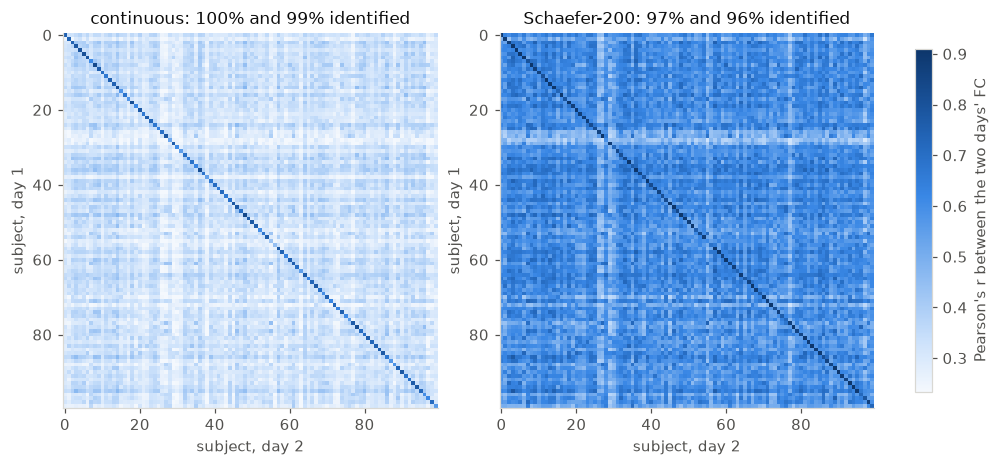

In [4]:
found = {
    "continuous": identification(fc["REST1"]["pairs"], fc["REST2"]["pairs"]),
    "Schaefer-200": identification(fc["REST1"]["regions"], fc["REST2"]["regions"]),
}
for name, result in found.items():
    print(f"{name:13s} {result.features:>10,} features: identified {result.accuracy[0]:.0%} day 1 to 2 "
          f"and {result.accuracy[1]:.0%} day 2 to 1; r with own other day {result.within:.3f}, "
          f"with another subject's {result.between:.3f}; differential identifiability "
          f"{100 * (result.within - result.between):.1f}")

figure, axes = plt.subplots(1, 2, figsize=(9, 4.2), constrained_layout=True)
values = np.concatenate([result.similarity.ravel() for result in found.values()])
low, high = np.percentile(values, [1, 99.9])
for axis, (name, result) in zip(axes, found.items(), strict=True):
    image = axis.imshow(result.similarity, cmap=BLUE_RAMP, vmin=low, vmax=high)
    axis.set_title(f"{name}: {result.accuracy[0]:.0%} and {result.accuracy[1]:.0%} identified",
                   fontsize=11)
    axis.set_xlabel("subject, day 2")
    axis.set_ylabel("subject, day 1")
figure.colorbar(image, ax=axes, shrink=0.8, label="Pearson's r between the two days' FC")
plt.show()

### Each connection on its own

One connection on its own is another matter. Between days a single pair of vertices has a median
ICC of 0.43, and a pair of Schaefer regions 0.59: averaging over the thousands of vertex pairs
between two regions removes noise that one pair keeps. By the usual reading of an ICC (below
0.5 poor, 0.5 to 0.75 moderate; Koo and Li, 2016) a vertex pair is poor on median and a region
pair moderate. What the continuous connectome adds is the whole pattern, as the identification
above shows, not a more reliable single connection.

continuous    edge ICC: median 0.429; 55% above 0.4, 23% above 0.6
Schaefer-200  edge ICC: median 0.585; 90% above 0.4, 46% above 0.6


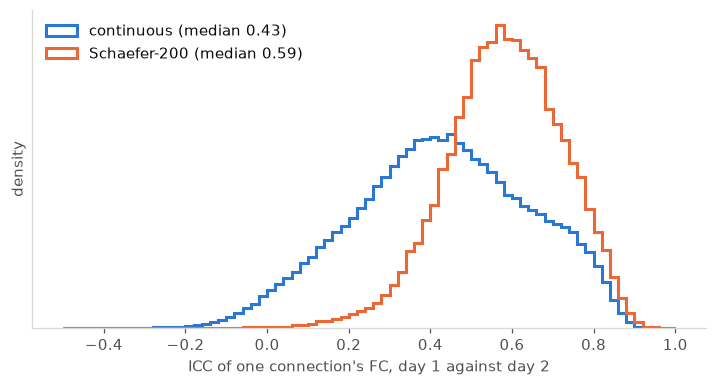

In [5]:
edge_icc = {
    "continuous": icc([fc["REST1"]["pairs"][:, sampled], fc["REST2"]["pairs"][:, sampled]]),
    "Schaefer-200": icc([fc["REST1"]["regions"], fc["REST2"]["regions"]]),
}
for name, values in edge_icc.items():
    print(f"{name:13s} edge ICC: median {np.nanmedian(values):.3f}; "
          f"{np.mean(values > 0.4):.0%} above 0.4, {np.mean(values > 0.6):.0%} above 0.6")

figure, axis = plt.subplots(figsize=(6.4, 3.4), constrained_layout=True)
bins = np.linspace(-0.5, 1.0, 76)
for (name, values), colour in zip(edge_icc.items(), (BLUE, ORANGE), strict=True):
    axis.hist(values[np.isfinite(values)], bins=bins, density=True, histtype="step", linewidth=2,
              color=colour, label=f"{name} (median {np.nanmedian(values):.2f})")
axis.set_xlabel("ICC of one connection's FC, day 1 against day 2")
axis.set_ylabel("density")
axis.set_yticks([])
axis.legend(frameon=False)
plt.show()

### Where FC repeats: each vertex's strength

Summed over a vertex's connections, FC repeats better than one connection does: each vertex's
strength has an ICC of 0.61 on median (0.47 to 0.71 over the middle 80% of vertices), and 0.65
averaged within Schaefer-200 regions. By the Desikan regions it is lowest in the entorhinal
cortex (0.34 and 0.35) and the right temporal pole (0.42), and highest in the pars orbitalis
(0.70 on both sides) and the left middle temporal gyrus (0.68). The map shares its scale, 0.3 to
0.9, with the coupling map below.

vertex strength ICC: median 0.605, 10th to 90th percentile 0.469 to 0.712
the same averaged in each Schaefer-200 region: median 0.652
FC strength ICC, highest: LH_parsorbitalis 0.70, RH_parsorbitalis 0.70, LH_middletemporal 0.68
FC strength ICC, lowest: LH_entorhinal 0.34, RH_entorhinal 0.35, RH_temporalpole 0.42


[fetch_surf_fsaverage] Dataset directory found: /nas/longleaf/home/xya/nilearn_data/fsaverage


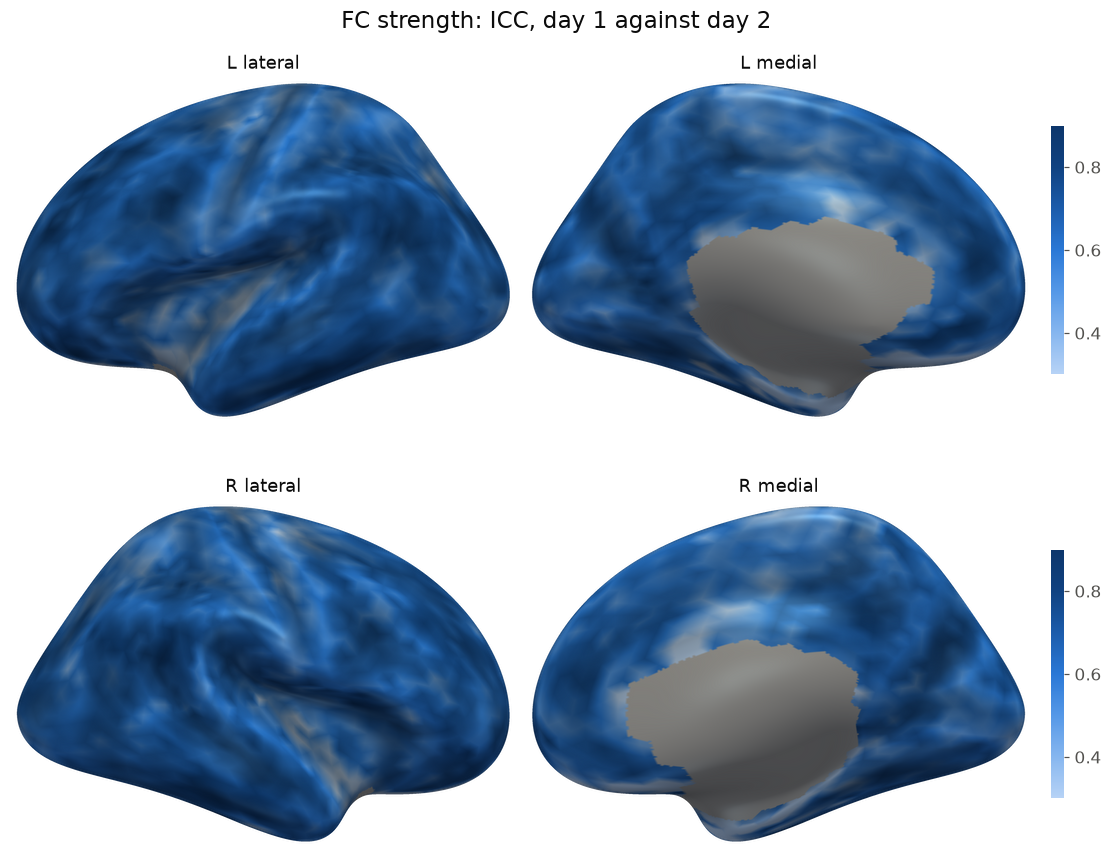

In [6]:
strength_icc = icc([fc["REST1"]["strength"], fc["REST2"]["strength"]])
region_strength = {day: np.vstack([sbci.region_means(row, schaefer) for row in fc[day]["strength"]]) for day in fc}
region_icc = icc([region_strength["REST1"], region_strength["REST2"]])
print(f"vertex strength ICC: median {np.nanmedian(strength_icc):.3f}, 10th to 90th percentile "
      f"{np.nanpercentile(strength_icc, 10):.3f} to {np.nanpercentile(strength_icc, 90):.3f}")
print(f"the same averaged in each Schaefer-200 region: median {np.nanmedian(region_icc):.3f}")
extremes(strength_icc, "FC strength ICC")
sbci.save_map({"icc": strength_icc}, OUT / "fc_strength_icc.dscalar.nii")
figure = surface(strength_icc, "FC strength: ICC, day 1 against day 2", scale=(0.3, 0.9))

## 2. Structure-function coupling across days

Coupling compares each vertex's structural profile with its functional one (`sc.coupling(fc)`,
the 2021 paper's global form, here with each subject's one SC against each day's FC). It averages
0.205 on day 1 and 0.206 on day 2, and its ICC is 0.67 on median, 0.50 to 0.79 over the middle
80% of vertices -- a little above FC strength's. It is highest in the inferior parietal cortex
(0.79 and 0.77) and the left pars opercularis (0.77), and lowest, as strength is, in the
entorhinal cortex (0.41 and 0.44) and the right temporal pole (0.50). The SC is the same on both
days, so this is
coupling's reliability as far as FC's change from day to day goes; a rescan of the diffusion
would add SC's own.

coupling, averaged over cortex and subjects: 0.205 on day 1, 0.206 on day 2
its ICC at each vertex: median 0.665, 10th to 90th percentile 0.500 to 0.789
coupling ICC, highest: LH_inferiorparietal 0.79, RH_inferiorparietal 0.77, LH_parsopercularis 0.77
coupling ICC, lowest: RH_entorhinal 0.41, LH_entorhinal 0.44, RH_temporalpole 0.50


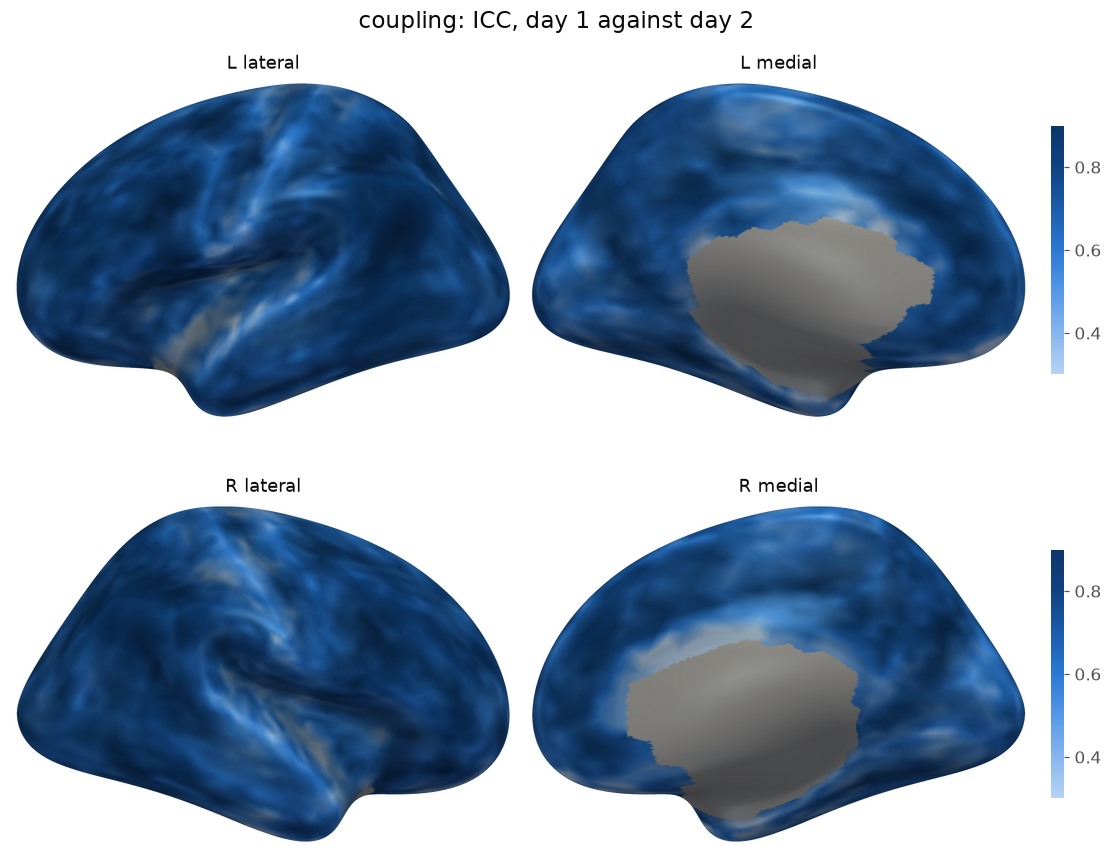

In [7]:
coupling = {"REST1": [], "REST2": []}
for subject, first, second in zip(subjects, days["REST1"].paths("fc"), days["REST2"].paths("fc"), strict=True):
    structural = sbci.load(SC / f"{subject}_sc.h5")
    coupling["REST1"].append(structural.coupling(sbci.load(first)))
    coupling["REST2"].append(structural.coupling(sbci.load(second)))
coupling = {day: np.vstack(maps) for day, maps in coupling.items()}
coupling_icc = icc([coupling["REST1"], coupling["REST2"]])
print(f"coupling, averaged over cortex and subjects: {np.nanmean(coupling['REST1']):.3f} on day 1, "
      f"{np.nanmean(coupling['REST2']):.3f} on day 2")
print(f"its ICC at each vertex: median {np.nanmedian(coupling_icc):.3f}, 10th to 90th percentile "
      f"{np.nanpercentile(coupling_icc, 10):.3f} to {np.nanpercentile(coupling_icc, 90):.3f}")
extremes(coupling_icc, "coupling ICC")
sbci.save_map({"icc": coupling_icc}, OUT / "coupling_icc.dscalar.nii")
figure = surface(coupling_icc, "coupling: ICC, day 1 against day 2", scale=(0.3, 0.9))

## 3. Structural connectivity: two halves of the streamlines, three bandwidths

Split in two, a subject's streamlines give two connectomes that agree almost perfectly as wholes
(r = 0.994 to 0.999) and pick out their subject every time, at every bandwidth: the halves share
everything but the sampling. The bandwidth decides the trade-off below. At 0.0025 a single
vertex pair is unreliable (median ICC 0.24) but a subject stands far out from the others
(differential identifiability 39.8); at 0.01 single pairs are reliable (0.84) but subjects look
alike (17.5). The released bandwidth, 0.005, sits between (0.58 and 28.0). The Schaefer-200
regions stand out less at every bandwidth (17.6 to 11.6). A pair of vertices that no subject's
streamlines reach is zero in both halves and has no ICC -- 15% of the sampled pairs at 0.0025,
4% at 0.005, 0.5% at 0.01 -- so single pairs are compared over the 170,000 sampled pairs that
vary at every bandwidth. A vertex's strength is reliable at any bandwidth (ICC 0.995; for the
whole set of streamlines, twice a half's, the Spearman-Brown formula gives 0.997).

In [8]:
split_subjects = sorted(path.name for path in SPLIT.iterdir() if (path / "alignment.npz").exists())
print(f"{len(split_subjects)} subjects split")
BANDWIDTHS = (0.0025, 0.005, 0.01)
by_bandwidth = {}
for bandwidth in BANDWIDTHS:
    stack = {}
    for half in "AB":
        loaded = [np.load(SPLIT / s / f"half{half}_bw{bandwidth}.npz") for s in split_subjects]
        stack[half] = {
            "pairs": np.vstack([item["pairs"] for item in loaded]),
            "regions": np.vstack([item["schaefer200"][upper200] for item in loaded]),
            "strength": np.vstack([np.where(cortex, item["strength"], np.nan) for item in loaded]),
        }
    row = {
        "continuous": identification(stack["A"]["pairs"], stack["B"]["pairs"]),
        "Schaefer-200": identification(stack["A"]["regions"], stack["B"]["regions"]),
        "strength": icc([stack["A"]["strength"], stack["B"]["strength"]]),
        "edges": icc([stack["A"]["pairs"][:, sampled], stack["B"]["pairs"][:, sampled]]),
    }
    by_bandwidth[bandwidth] = row
    print(f"bandwidth {bandwidth}:")
    for name in ("continuous", "Schaefer-200"):
        result = row[name]
        print(f"  {name:13s} identified {np.mean(result.accuracy):.0%}; r with own other half {result.within:.3f}, "
              f"with another subject's {result.between:.3f}; differential identifiability "
              f"{100 * (result.within - result.between):.1f}")
    half_icc = np.nanmedian(row["strength"])
    print(f"  vertex strength ICC median {half_icc:.3f} (the whole set's, by Spearman-Brown, "
          f"{2 * half_icc / (1 + half_icc):.3f})")
# A pair no subject's streamlines reach is zero in every half and has no ICC; how many there are
# falls as the bandwidth widens, so the edges are compared over the pairs that vary at every one.
varying = np.all([np.isfinite(by_bandwidth[b]["edges"]) for b in BANDWIDTHS], axis=0)
for bandwidth in BANDWIDTHS:
    edges = by_bandwidth[bandwidth]["edges"]
    print(f"bandwidth {bandwidth}: {np.mean(np.isnan(edges)):.1%} of the sampled pairs zero in every half; "
          f"over the {varying.sum():,} that vary at every bandwidth, edge ICC median {np.median(edges[varying]):.3f}")

30 subjects split


bandwidth 0.0025:
  continuous    identified 100%; r with own other half 0.994, with another subject's 0.596; differential identifiability 39.8
  Schaefer-200  identified 100%; r with own other half 0.999, with another subject's 0.823; differential identifiability 17.6
  vertex strength ICC median 0.994 (the whole set's, by Spearman-Brown, 0.997)


bandwidth 0.005:
  continuous    identified 100%; r with own other half 0.997, with another subject's 0.717; differential identifiability 28.0
  Schaefer-200  identified 100%; r with own other half 0.999, with another subject's 0.849; differential identifiability 15.0
  vertex strength ICC median 0.995 (the whole set's, by Spearman-Brown, 0.997)


bandwidth 0.01:
  continuous    identified 100%; r with own other half 0.999, with another subject's 0.824; differential identifiability 17.5
  Schaefer-200  identified 100%; r with own other half 0.999, with another subject's 0.883; differential identifiability 11.6
  vertex strength ICC median 0.996 (the whole set's, by Spearman-Brown, 0.998)
bandwidth 0.0025: 15.1% of the sampled pairs zero in every half; over the 169,876 that vary at every bandwidth, edge ICC median 0.236
bandwidth 0.005: 4.4% of the sampled pairs zero in every half; over the 169,876 that vary at every bandwidth, edge ICC median 0.583
bandwidth 0.01: 0.5% of the sampled pairs zero in every half; over the 169,876 that vary at every bandwidth, edge ICC median 0.838


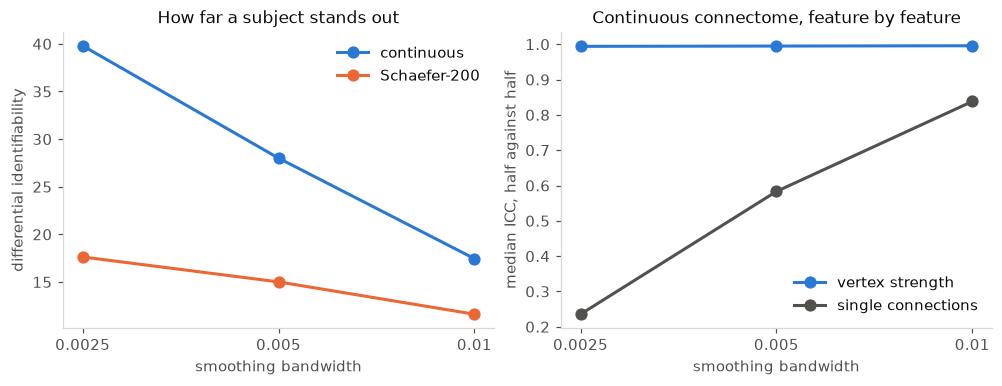

In [9]:
figure, (left, right) = plt.subplots(1, 2, figsize=(9, 3.4), constrained_layout=True)
for name, colour in (("continuous", BLUE), ("Schaefer-200", ORANGE)):
    gaps = [100 * (by_bandwidth[b][name].within - by_bandwidth[b][name].between) for b in BANDWIDTHS]
    left.plot(BANDWIDTHS, gaps, "o-", color=colour, linewidth=2, markersize=7, label=name)
left.set_ylabel("differential identifiability")
left.set_title("How far a subject stands out", fontsize=11)
left.legend(frameon=False)
for name, key, colour in (("vertex strength", "strength", BLUE), ("single connections", "edges", MUTED)):
    medians = [np.median(by_bandwidth[b][key][varying]) if key == "edges" else np.nanmedian(by_bandwidth[b][key])
               for b in BANDWIDTHS]
    right.plot(BANDWIDTHS, medians, "o-", color=colour, linewidth=2, markersize=7, label=name)
right.set_ylabel("median ICC, half against half")
right.set_title("Continuous connectome, feature by feature", fontsize=11)
right.legend(frameon=False)
for axis in (left, right):
    axis.set_xscale("log")
    axis.set_xticks(BANDWIDTHS, [str(b) for b in BANDWIDTHS])
    axis.minorticks_off()
    axis.set_xlabel("smoothing bandwidth")
plt.show()

## 4. How many components are reliable

A rank-20 functional PCA fitted to thirty other subjects of the sample, none of them split,
with both halves of every split subject scored on it by `sbci.project`, gives every component
an ICC of 0.994 to 0.999 between halves -- as a basis fitted to the split subjects themselves
did (0.995 to 0.999), so the agreement is not the basis's doing. What the finite number of
streamlines costs a subject's component scores is nothing measurable: the smoothing and the
projection onto smooth components average it away. The twenty components hold 32% of their
thirty subjects' norm.

In [10]:
fitted = np.load(SPLIT / "components.npz")
component_icc = icc([fitted["first"], fitted["second"]])
print(f"{component_icc.size} components, fitted to thirty other subjects ({fitted['explained'][-1]:.1%} of "
      f"their norm): ICC {component_icc.min():.3f} to {component_icc.max():.3f} between halves")
for k, value in enumerate(component_icc):
    print(f"  component {k + 1:2d}: ICC {value:.3f}; with the ones before, "
          f"{fitted['explained'][k]:.1%} of the norm")

20 components, fitted to thirty other subjects (32.4% of their norm): ICC 0.994 to 0.999 between halves
  component  1: ICC 0.998; with the ones before, 11.3% of the norm
  component  2: ICC 0.996; with the ones before, 14.8% of the norm
  component  3: ICC 0.996; with the ones before, 17.5% of the norm
  component  4: ICC 0.998; with the ones before, 19.8% of the norm
  component  5: ICC 0.997; with the ones before, 21.3% of the norm
  component  6: ICC 0.998; with the ones before, 22.3% of the norm
  component  7: ICC 0.999; with the ones before, 23.9% of the norm
  component  8: ICC 0.999; with the ones before, 25.0% of the norm
  component  9: ICC 0.999; with the ones before, 25.6% of the norm
  component 10: ICC 0.999; with the ones before, 26.1% of the norm
  component 11: ICC 0.995; with the ones before, 27.4% of the norm
  component 12: ICC 0.995; with the ones before, 28.0% of the norm
  component 13: ICC 0.994; with the ones before, 29.1% of the norm
  component 14: ICC 0.997

## 5. Alignment: two samples of one brain against two brains

ENCORE aligning one half of a subject's streamlines onto the other moves the cortex 0.11 degrees
on median (0.09 to 0.12 across the thirty subjects): alignment's own noise, since the two halves
are one brain. Aligning the next subject's streamlines onto them moves it 3.07 degrees (2.44 to
3.85), some 28 times as far. The noise is largest in the transverse and superior temporal gyri
(0.14 degrees) and smallest in the lateral occipital cortex and the cuneus (0.09 to 0.10), as
the map shows.

a subject's second half aligned onto its first: median displacement 0.11 degrees (subjects 0.09 to 0.12)
the next subject aligned onto it: 3.07 degrees (2.44 to 3.85)


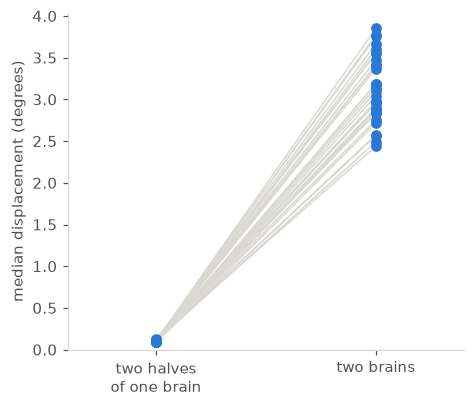

displacement between halves (degrees), highest: RH_transversetemporal 0.141, LH_transversetemporal 0.138, RH_superiortemporal 0.137
displacement between halves (degrees), lowest: RH_lateraloccipital 0.092, RH_cuneus 0.095, LH_lateraloccipital 0.096


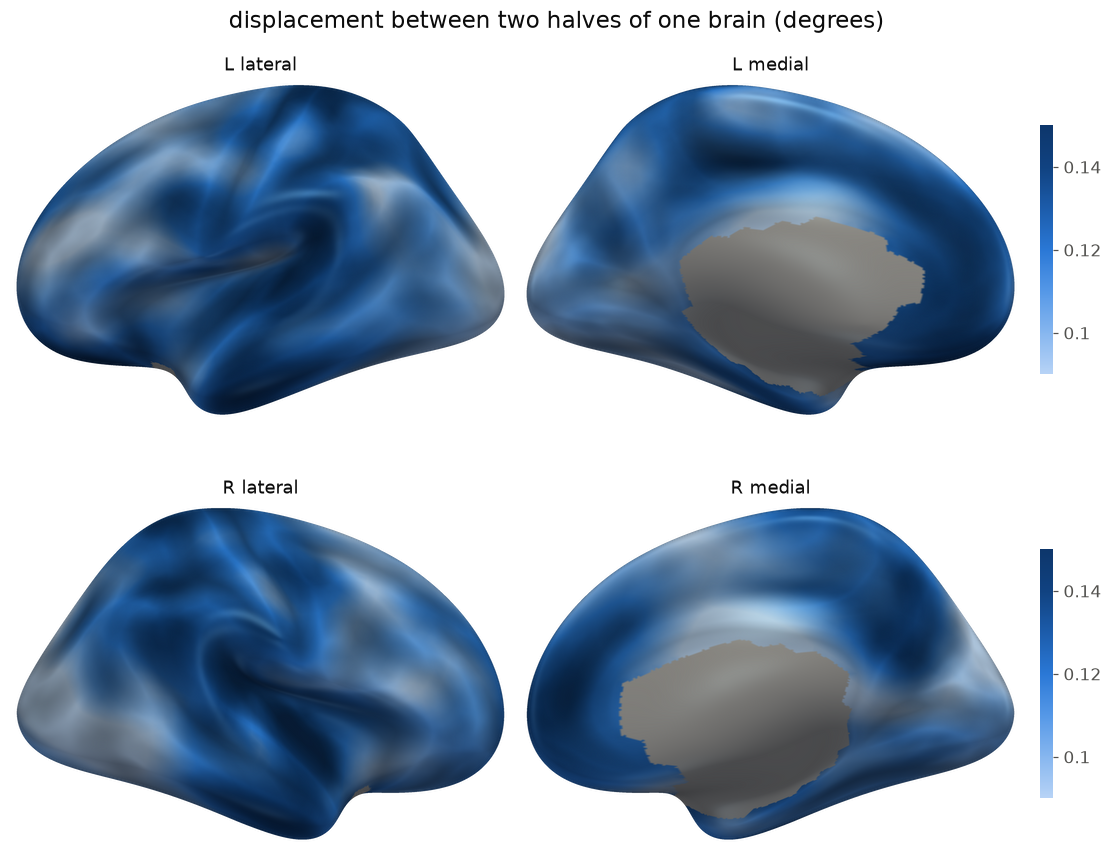

In [11]:
moved = [np.load(SPLIT / s / "alignment.npz") for s in split_subjects]
within = np.array([np.median(item["within"][cortex]) for item in moved])
between = np.array([np.median(item["between"][cortex]) for item in moved])
print(f"a subject's second half aligned onto its first: median displacement {np.median(within):.2f} degrees "
      f"(subjects {within.min():.2f} to {within.max():.2f})")
print(f"the next subject aligned onto it: {np.median(between):.2f} degrees ({between.min():.2f} to {between.max():.2f})")

figure, axis = plt.subplots(figsize=(4.2, 3.6), constrained_layout=True)
for one, two in zip(within, between, strict=True):
    axis.plot([0, 1], [one, two], color=RULE, linewidth=1, zorder=1)
axis.scatter(np.zeros_like(within), within, s=36, color=BLUE, zorder=2)
axis.scatter(np.ones_like(between), between, s=36, color=BLUE, zorder=2)
axis.set_xticks([0, 1], ["two halves\nof one brain", "two brains"])
axis.set_xlim(-0.4, 1.4)
axis.set_ylim(0, None)
axis.set_ylabel("median displacement (degrees)")
plt.show()

mean_within = np.mean([item["within"] for item in moved], axis=0)
mean_within[~cortex] = np.nan
extremes(mean_within, "displacement between halves (degrees)", digits=3)
figure = surface(mean_within, "displacement between two halves of one brain (degrees)")

## What this says

- **Across days**, the continuous FC connectome identifies its subject more surely than
  Schaefer-200 regions do (100% and 99% against 97% and 96%) and sets subjects further apart
  (differential identifiability 37.5 against 26.6), while a single vertex pair is less reliable
  than a region pair (median
  ICC 0.43 against 0.59). For individual differences that is the better trade; for one
  connection read on its own it is not.
- **Summaries repeat better than connections**: a vertex's FC strength (ICC 0.61 on median) and
  its coupling (0.67) across days, and component scores almost perfectly across halves of the
  streamlines.
- **The smoothing bandwidth** trades a connection's reliability against how far a subject stands
  out; the released 0.005 sits between.
- **Alignment's own noise** is a small fraction of the warp between two subjects (0.11 against
  3.07 degrees on median).